
# 1D Gaussian With No Observations: PyMC Trajectories on the Exact Objective

This notebook is organized around the exact PyMC trajectory paths on the exact objective level curves.

The main questions are:

1. Where do the four PyMC runs move in objective space?
2. When we zoom in near the global optimum, where does each run spend its late iterations?
3. At one late step from each run, what step does PyMC actually take, what values go into that step, and where does each of those values come from?


In [ ]:
# imports
import os
from pathlib import Path
import sys


os.environ.setdefault('MPLCONFIGDIR', '/tmp/mpl')
os.environ.setdefault('PYTENSOR_FLAGS', 'base_compiledir=/tmp/pytensor,compiledir=/tmp/pytensor/compiledir')

import pytensor
pytensor.config.cxx = '/usr/bin/clang++'

ROOT = Path.cwd()
if not (ROOT / 'modulars').exists():
    for parent in ROOT.parents:
        if (parent / 'modulars').exists():
            ROOT = parent
            break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
from scipy.special import expit
from scipy.optimize import brentq

from modulars.distributions import gaussian_1d_posterior

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'lines.linewidth': 1.1,
})
np.set_printoptions(precision=4, suppress=True)


In [2]:
# setup and configs
MU_PRIOR = 0.0
SIGMA_PRIOR = 10.0
SIGMA_LIKE = 1.0
OBSERVED = np.array([])
FIT_ITERS = 150_000
VALIDATION_ITERS = 5_000
BASE_SEED = 42
# the starting iteration for the "inspection" at the end
INSPECT_IDX = FIT_ITERS - 1_000
MAIN_ZOOM_PLOT_WINDOW = 5_000
MAIN_ZOOM_LIMIT_WINDOW = 5_000
INSPECTION_ZOOM_LIMIT_WINDOW = 3_000
TAIL_FOR_SUMMARY = 5_000
TRAJ_ALPHA = 0.7
TRAJ_LW = 1.1
CONTOUR_ALPHA = 0.7
CONTOUR_LW = 0.9
FULL_LEVELS = np.array([1e-7, 3e-7, 1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0])
ZOOM_LEVELS = np.array([1e-8, 3e-8, 1e-7, 3e-7, 1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3])


RUN_SPECS = [
    {'name': 'AdagradWindow, 1 MC', 'optimizer_name': 'adagrad_window', 'n_mc': 1, 'color': '#1f77b4', 'short': 'AW-1'},
    {'name': 'AdagradWindow, 100 MC', 'optimizer_name': 'adagrad_window', 'n_mc': 100, 'color': '#2ca02c', 'short': 'AW-100'},
    {'name': 'Adam, 1 MC', 'optimizer_name': 'adam', 'n_mc': 1, 'color': '#d62728', 'short': 'AD-1'},
    {'name': 'Adam, 100 MC', 'optimizer_name': 'adam', 'n_mc': 100, 'color': '#ff7f0e', 'short': 'AD-100'},
]
RUN_BY_NAME = {spec['name']: spec for spec in RUN_SPECS}

from modulars.utils import softplus, inv_softplus
from modulars.distributions import rho_from_std, exact_kl, exact_kl_sigma, exact_grad, exact_g_rho_from_sigma
from modulars.pymc_rr_test import run_actual_pymc_fit, run_actual_suite, print_actual_summary
from modulars.plot_rr import make_contour_grid_rho, make_contour_grid_sigma, compute_full_limits, draw_trajectory, draw_contours


# compute true posterior parameters and the corresponding rho_star value which is the parameterized sigma value of the true posterior
true_mu, true_sigma = gaussian_1d_posterior(
    OBSERVED,
    n_samples=0,
    mu_prior=MU_PRIOR,
    sigma_prior=SIGMA_PRIOR,
    sigma_like=SIGMA_LIKE,
)
rho_star = float(inv_softplus(true_sigma))

# a model factory function. This is included in this notebook so that users can see what pymc model we are using.
def make_model():
    with pm.Model() as model:
        mu = pm.Normal('mu', MU_PRIOR, SIGMA_PRIOR)
        pm.Normal('y', mu=mu, sigma=SIGMA_LIKE, observed=np.array([]))
    return model



## Setup

With no observations, the posterior is exactly the prior:

$$
p(z) = \mathcal N(0, 10^2), \qquad q(z) = \mathcal N(\mu, \sigma^2), \qquad \sigma = \operatorname{softplus}(\rho).
$$

PyMC's ADVI minimizes

$$
\mathcal L(\mu, \rho) = \mathrm{KL}\big(q(z;\mu,\sigma)\,\|\,p(z)\big)
= \log\frac{10}{\sigma} + \frac{\sigma^2 + \mu^2}{200} - \frac12.
$$

So the exact global optimum is

$$
\mu^* = 0, \qquad \sigma^* = 10, \qquad \rho^* = \operatorname{softplus}^{-1}(10).
$$

All contour plots below are level curves of this exact KL objective.


In [12]:
from modulars.plot_rr import *
import modulars.plot_rr

import importlib
import modulars
importlib.reload(modulars.plot_rr)
from modulars.plot_rr import *
def plot_main_trajectory_figure(actual_runs, zoom_limits={}):
    zoom_limits = {} if zoom_limits is None else zoom_limits
    full_limits = compute_full_limits(actual_runs, rho_star, true_sigma)
    panel_specs = make_panel_specs(
        *full_limits,
        zoom_limits,
        FULL_LEVELS, ZOOM_LEVELS,
        rho_star, true_sigma
    )

    fig, axes = create_trajectory_figure(panel_specs)

    for panel in panel_specs:
        draw_panel_contours(panel)

    draw_all_trajectories(panel_specs, actual_runs, RUN_SPECS)
    modulars.plot_rr.draw_final_points(panel_specs, actual_runs, RUN_SPECS)

    for panel in panel_specs:
        format_panel(panel, true_mu)

    add_zoom_panel_legends(axes)

    fig.tight_layout()
    plt.show()

In [ ]:
from modulars.pymc_rr_test import compile_pymc_ADVI_update, run_full_pymc_ADVI, validate_pymc_copy, attach_exact_gradients, infer_noise_moments, build_inspection_dataframe, print_step_breakdown, late_noise_summary, summarize_aw1_empirical_steady_state

# compile_pymc_ADVI_update(make_model, n_mc, optimizer_name, seed)
# run_full_pymc_ADVI(n_iters, n_mc, optimizer_name, seed=42, mu_p=MU_PRIOR, sigma_p=SIGMA_PRIOR)
# validate_pymc_copy(make_model, seed=42, RUN_SPECS=RUN_SPECS, VALIDATION_ITERS=VALIDATION_ITERS, mu_p=MU_PRIOR, sigma_p=SIGMA_PRIOR)




def run_accessible_ADVI_suite(n_iters, seed=42):
    """Run the instrumented our_copy for all four optimizer / MC settings."""
    return {
        spec['name']: run_full_pymc_ADVI(n_iters, spec['n_mc'], spec['optimizer_name'], seed=seed, mu_p=MU_PRIOR, sigma_p=SIGMA_PRIOR)
        for spec in RUN_SPECS
    }

from modulars.plot_rr import plot_inspection_points, plot_step_inputs



print(f'Exact posterior mean  : {true_mu:.4f}')
print(f'Exact posterior sigma : {true_sigma:.4f}')
print(f'Exact optimizer-space optimum (mu, rho): ({true_mu:.4f}, {rho_star:.4f})')


Exact posterior mean  : 0.0000
Exact posterior sigma : 10.0000
Exact optimizer-space optimum (mu, rho): (0.0000, 10.0000)



## Actual PyMC Runs

We start with the real `pm.ADVI.fit(...)` trajectories for `150,000` iterations.


In [5]:

actual_runs = run_actual_suite(make_model,FIT_ITERS, RUN_SPECS, seed=BASE_SEED, mu_p=MU_PRIOR, sigma_p=SIGMA_PRIOR)
print_actual_summary(actual_runs, RUN_SPECS)


Finished [100%]: Average Loss = 0.0058362
Finished [100%]: Average Loss = 1.2558e-06
Finished [100%]: Average Loss = 0.00055738
Finished [100%]: Average Loss = 1.2609e-05


AdagradWindow, 1 MC | final mean = -0.02442762193030844 | final std = 10.484538522065499 | final KL = 0.0023141664111252513
AdagradWindow, 100 MC | final mean = -0.0016977075282020387 | final std = 9.998836123569452 | final KL = 2.7957663406574795e-08
Adam, 1 MC | final mean = -0.019676298802877003 | final std = 10.024620249755515 | final KL = 7.992385244293132e-06
Adam, 100 MC | final mean = -0.02116116466634793 | final std = 10.003045983135506 | final KL = 2.3317451647297815e-06



## Plot 1: PyMC Trajectories on the Exact Objective Level Curves

What this plot is trying to show:

- The full-view panels show the global path from the ADVI start to the optimum basin.
- The zoomed panels contain the exact optimum and show a zoomed in view of the ADVI runs.
- The dashed curves are exact KL level curves.

Other aspects:

- Black `x`: ADVI start.
- Black `*`: exact optimum.
- Colored points: final PyMC iterate after `150,000` iterations.
- The thinner semi-transparent trajectories make overlap visible where runs travel through the same region.


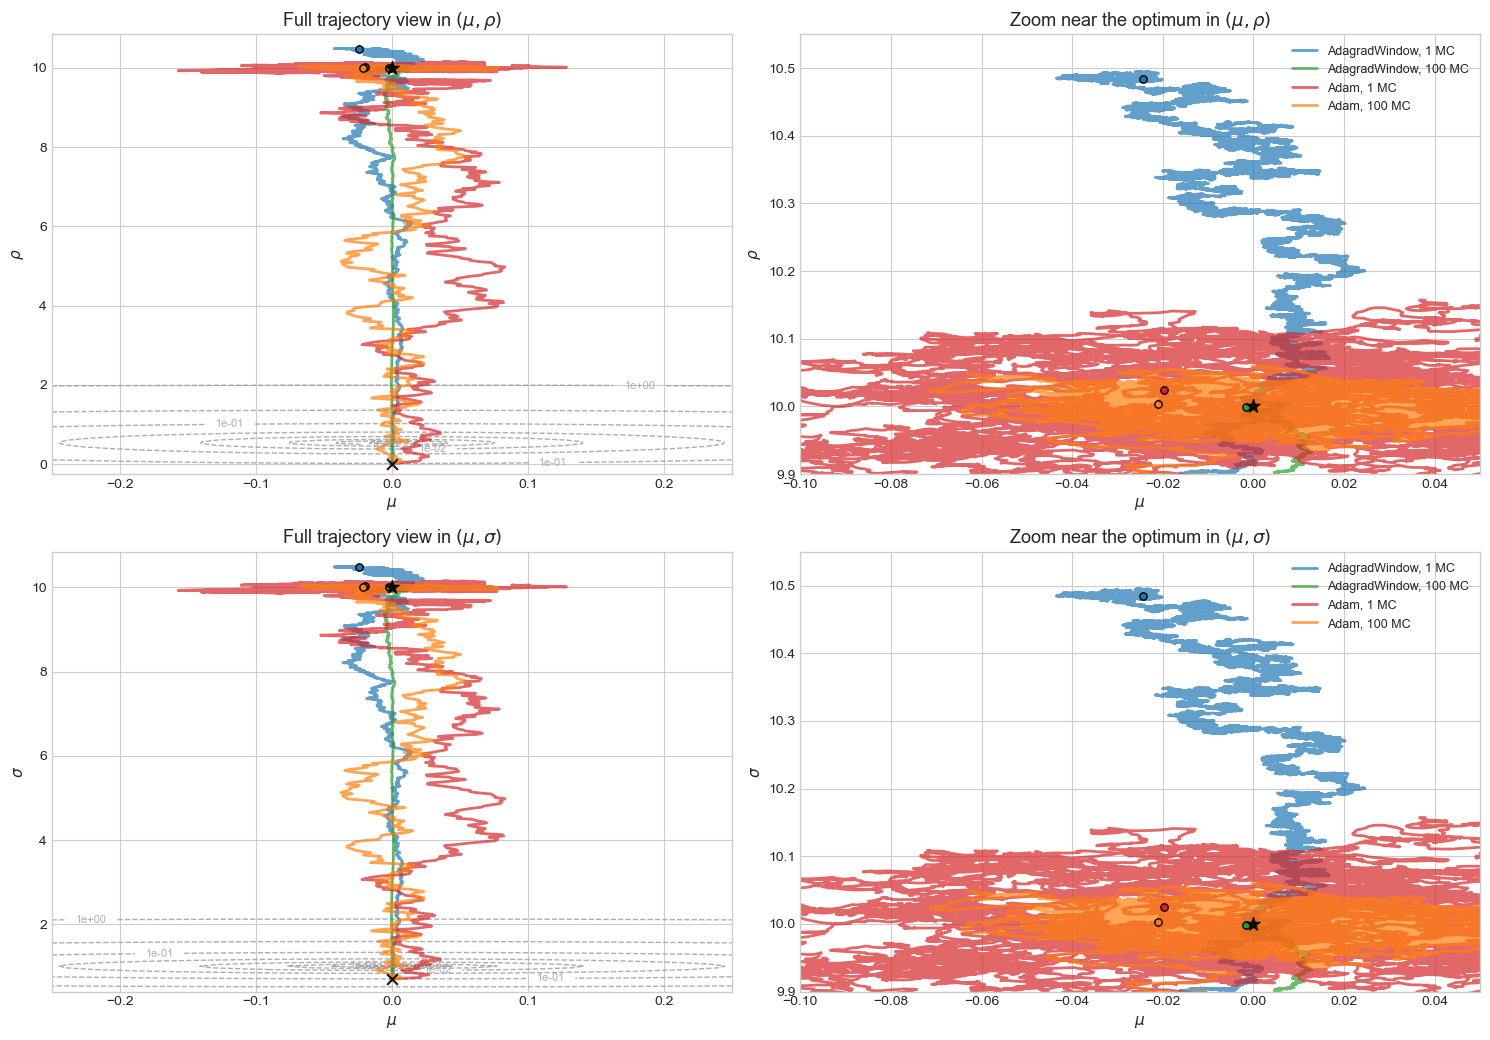

In [13]:
plot_main_trajectory_figure(actual_runs, zoom_limits={'mu_zoom_lim': (-0.10, 0.05),'rho_zoom_lim': (9.9, 10.55), 'sigma_zoom_lim': (9.9, 10.55)})


In [14]:
for key in actual_runs.keys():
    print(actual_runs[key].keys())

dict_keys(['mean', 'std', 'rho', 'kl'])
dict_keys(['mean', 'std', 'rho', 'kl'])
dict_keys(['mean', 'std', 'rho', 'kl'])
dict_keys(['mean', 'std', 'rho', 'kl'])



What this means:

All four runs descend the same exact KL surface and enter the same basin of attraction. The important difference is the late-iteration neighborhood each optimizer and Monte Carlo setting occupies on that same surface.



## A Short our_copy Check

To inspect optimizer internals, the notebook uses a step-by-step our_copy of the PyMC update equations. Before using it for diagnosis, we verify that the our_copy reproduces the actual `pm.ADVI.fit(...)` path.


In [ ]:

validate_pymc_copy(make_model, seed=BASE_SEED, RUN_SPECS=RUN_SPECS, VALIDATION_ITERS=VALIDATION_ITERS, mu_p=MU_PRIOR, sigma_p=SIGMA_PRIOR)


Finished [100%]: Average Loss = 1.3434
Finished [100%]: Average Loss = 1.3332
Finished [100%]: Average Loss = 0.56658
Finished [100%]: Average Loss = 0.5563


AdagradWindow, 1 MC      | max |mean diff| = 2.385e-18 | max |std diff| = 0.000e+00
AdagradWindow, 100 MC    | max |mean diff| = 4.235e-19 | max |std diff| = 4.441e-16
Adam, 1 MC               | max |mean diff| = 5.551e-17 | max |std diff| = 2.665e-15
Adam, 100 MC             | max |mean diff| = 4.163e-17 | max |std diff| = 2.665e-15



## The Step Calculations in each optimizer

The quantity we ultimately care about is the parameter step

$$
\Delta \theta_t = \theta_{t+1} - \theta_t.
$$

PyMC gets that step in two stages:

1. it forms a stochastic Monte Carlo gradient from the current parameter values and the current reparameterization-noise draws
2. the optimizer turns that gradient into a step using its internal state

For this Gaussian problem, let

$$
z_i = \mu + \sigma \vepsilon_i, \qquad \vepsilon_i \sim \mathcal N(0,1), \qquad \sigma = \operatorname{softplus}(\rho).
$$

Define the two sampled averages

$$
\text{noise\_mean} = \frac1M \sum_{i=1}^M \vepsilon_i,
\qquad
\text{noise\_second\_moment} = \frac1M \sum_{i=1}^M \vepsilon_i^2.
$$

Then the stochastic loss gradients are

$$
g_\mu^{\text{MC}} = \frac{\mu + \sigma\,\text{noise\_mean}}{100}
$$

and

$$
g_\rho^{\text{MC}} = \operatorname{sigmoid}(\rho)
\left[
\frac{\mu\,\text{noise\_mean} + \sigma\,\text{noise\_second\_moment}}{100} - \frac{1}{\sigma}
\right].
$$

For `AdagradWindow`, PyMC uses

$$
\text{window\_sum}_t = \sum_{k=t-9}^t g_k^2,
\qquad
\text{denom}_t = \sqrt{\text{window\_sum}_t + 0.1},
\qquad
\text{step}_t = 0.001\,\frac{g_t}{\text{denom}_t},
\qquad
\Delta\theta_t = -\text{step}_t.
$$

For `Adam`, PyMC uses

$$
m_t = 0.9m_{t-1} + 0.1g_t,
\qquad
v_t = 0.999v_{t-1} + 0.001g_t^2,
\qquad
a_t = 0.001\,\frac{\sqrt{1-0.999^t}}{1-0.9^t},
$$

$$
\text{denom}_t = \sqrt{v_t} + 10^{-8},
\qquad
\text{step}_t = a_t\frac{m_t}{\text{denom}_t},
\qquad
\Delta\theta_t = -\text{step}_t.
$$


In [ ]:

long_runs = run_accessible_ADVI_suite(FIT_ITERS, seed=BASE_SEED)
attach_exact_gradients(long_runs, mu_p=MU_PRIOR, sigma_p=SIGMA_PRIOR)



## Plot 2: Where the Late Inspection Points Sit on the Contours

We inspect the same late iteration in each run: the step `500` iterations before the end. These marked points are the states whose actual steps and step inputs we analyze in the next sections.


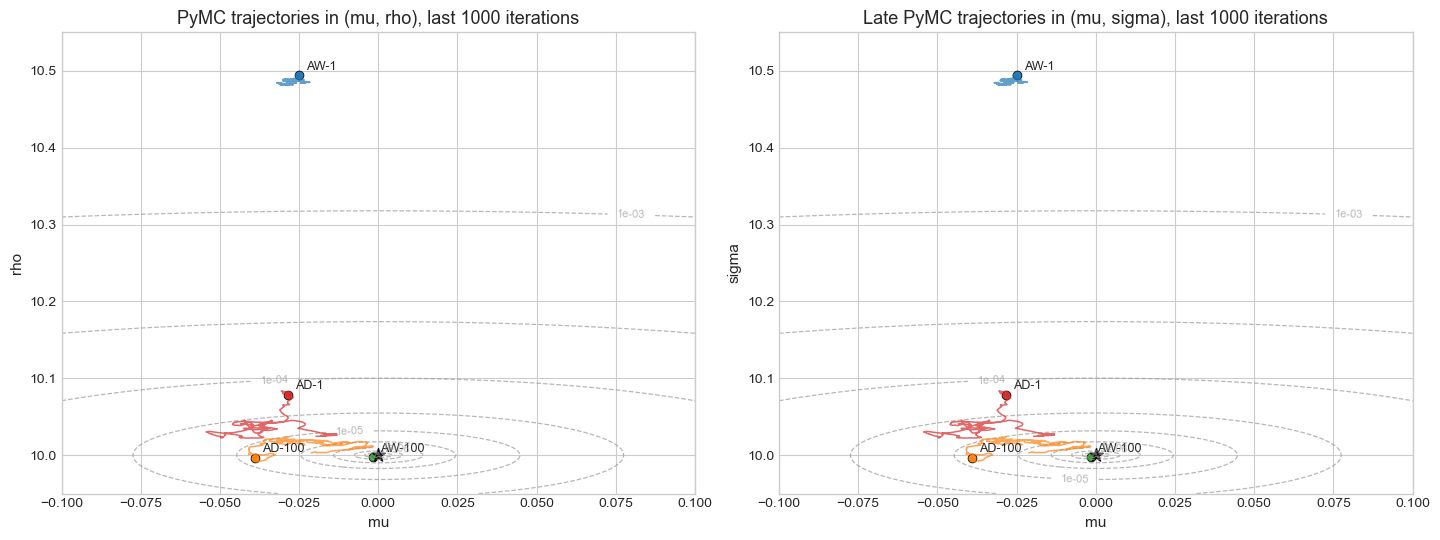

In [ ]:

plot_inspection_points(actual_runs, long_runs, INSPECT_IDX, FIT_ITERS, rho_star, true_sigma, ZOOM_LEVELS, RUN_SPECS, true_mu)


What this means:

The four late inspection points all lie in the same basin, but not on the same contour. The relevant question is whether the step computed from each point is small and coherent enough to keep the run close to the optimum, or noisy enough to kick it back out across a wider contour ring.


In [ ]:

inspect_df = build_inspection_dataframe(long_runs, inspect_idx=INSPECT_IDX, RUN_SPECS=RUN_SPECS, mu_p=MU_PRIOR, sigma_p=SIGMA_PRIOR)
print(
    inspect_df[
        ['run', 'iter', 'sigma', 'exact_g_rho', 'mc_g_rho', 'noise_mean', 'noise_second_moment', 'delta_rho']
    ].round(6)
)


                     run    iter      sigma  exact_g_rho  mc_g_rho  \
0    AdagradWindow, 1 MC  149000  10.494088     0.009649 -0.059697   
1  AdagradWindow, 100 MC  149000   9.997414    -0.000052 -0.018169   
2             Adam, 1 MC  149000  10.078210     0.001558 -0.065012   
3           Adam, 100 MC  149000   9.996325    -0.000074 -0.018147   

   noise_mean  noise_second_moment  delta_rho  
0   -0.581197             0.337790   0.000151  
1   -0.111552             0.818752   0.000057  
2   -0.581197             0.337790   0.000357  
3   -0.111552             0.818752  -0.000357  



## Plot 3: The Actual Inputs to the Optimizer Update

This figure follows the same order PyMC uses when computing the step:

1. sampled reparameterization-noise averages
2. the current stochastic gradient built from those samples
3. the actual `rho` step after optimizer-specific rescaling or filtering


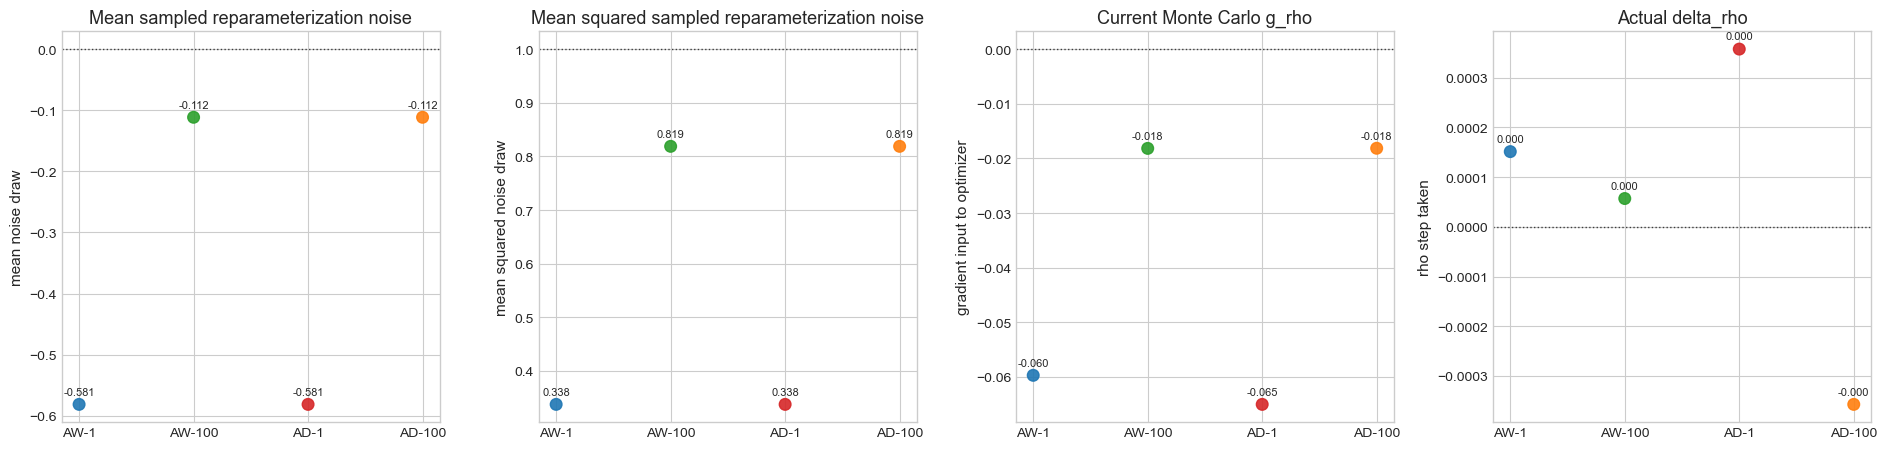

In [ ]:

plot_step_inputs(inspect_df, RUN_BY_NAME)
# g_rho is the MC gradient with respect to rho and delta_rho is the actual step taken in rho at that iteration, which is -step_rho in the code above since the optimizers do param = param - step.
# The noise_mean and noise_second_moment are the inferred mean and second moment of the sampled reparameterization noise at that iteration, which are the values that go into building the Monte Carlo gradient g_rho.


What this means:

The contour plots show where the run is. This figure shows how the sampled noise at that point gets converted into the actual step PyMC takes from that point.



## Step Substitution at the Chosen Late Steps

The next cell substitutes the actual late-step numbers into the optimizer equations, so we can see exactly how each run's `rho` step was computed and where each quantity came from.


In [62]:

print_step_breakdown(inspect_df)



AdagradWindow, 1 MC
Var. Approx. values: mu=-0.025000, rho=10.494061, sigma=10.494088, sigmoid(rho)=0.999972
Actual step vector at this iteration: delta_mu=0.000162, delta_rho=0.000151
Current Monte Carlo inputs:
  noise_mean is the average of the sampled reparameterization noise draws epsilon_i used at this iteration.
  noise_second_moment is the average of epsilon_i^2 over the same draws.
  noise_mean=-0.581197, noise_second_moment=0.337790
Current stochastic rho gradient built from those values:
  g_rho^MC = sigmoid(rho) * ((mu * noise_mean + sigma * noise_second_moment)/100 - 1/sigma)
           = 0.999972 * (((-0.025000 * -0.581197) + (10.494088 * 0.337790)) / 100 - 0.095292)
           = 0.999972 * (-0.059698) = -0.059697
AdagradWindow rho step:
  window_sum_rho comes from the last 10 squared rho-gradients stored by the optimizer.
  window_sum_rho=0.055950
  denom_rho = sqrt(window_sum_rho + 0.1)
            = sqrt(0.055950 + 0.1) = 0.394905
  raw step_rho = 0.001 * g_rho^MC / d

In [ ]:
noise_df = late_noise_summary(long_runs, TAIL_FOR_SUMMARY, RUN_SPECS, true_sigma)

aw1 = inspect_df.loc[inspect_df['run'] == 'AdagradWindow, 1 MC'].iloc[0]
aw100 = inspect_df.loc[inspect_df['run'] == 'AdagradWindow, 100 MC'].iloc[0]
adam1 = inspect_df.loc[inspect_df['run'] == 'Adam, 1 MC'].iloc[0]

print(f"theoretical sd(g_rho^MC), 1 MC   = {np.sqrt(0.02):.4f}")
print(f"theoretical sd(g_rho^MC), 100 MC = {np.sqrt(0.02 / 100):.4f}")
print()
print(f"AdagradWindow, 1 MC: exact g_rho = {aw1['exact_g_rho']:.4f}, sampled g_rho = {aw1['mc_g_rho']:.4f}, delta_rho = {aw1['delta_rho']:.6f}")
print(f"AdagradWindow, 1 MC: noise_second_moment = {aw1['noise_second_moment']:.4f}")
print(f"AdagradWindow, 100 MC: sampled g_rho = {aw100['mc_g_rho']:.4f}, delta_rho = {aw100['delta_rho']:.6f}")
print(f"gradient-magnitude ratio |1 MC| / |100 MC| = {abs(aw1['mc_g_rho']) / abs(aw100['mc_g_rho']):.2f}x")
print(f"step-magnitude ratio |1 MC| / |100 MC| = {abs(aw1['delta_rho']) / abs(aw100['delta_rho']):.2f}x")
print()
print(f"Adam, 1 MC: current g_rho = {adam1['mc_g_rho']:.4f}, momentum m_rho = {adam1['m_rho']:.4f}")
print()
print(noise_df.round(6).to_string(index=False))


theoretical sd(g_rho^MC), 1 MC   = 0.1414
theoretical sd(g_rho^MC), 100 MC = 0.0141

AdagradWindow, 1 MC: exact g_rho = 0.0096, sampled g_rho = -0.0597, delta_rho = 0.000151
AdagradWindow, 1 MC: noise_second_moment = 0.3378
AdagradWindow, 100 MC: sampled g_rho = -0.0182, delta_rho = 0.000057
gradient-magnitude ratio |1 MC| / |100 MC| = 3.29x
step-magnitude ratio |1 MC| / |100 MC| = 2.66x

Adam, 1 MC: current g_rho = -0.0650, momentum m_rho = -0.0471

                  run  sd_mc_g_rho  sd_delta_rho  mean_abs_sigma_error  mean_abs_exact_g_rho
  AdagradWindow, 1 MC     0.149044      0.000238              0.486318              0.009501
AdagradWindow, 100 MC     0.014340      0.000045              0.003632              0.000073
           Adam, 1 MC     0.143001      0.000238              0.059380              0.001184
         Adam, 100 MC     0.014369      0.000221              0.015716              0.000314



## Empirical Steady-State Check for `AdagradWindow, 1 MC`


For an iteration-to-iteration steady state, the average next $\rho$ step should be zero. So define the state-averaged drift curve

$$
D(\sigma)
=
\frac{1}{T}\sum_{t=1}^T
\mathbb E_{\varepsilon}\left[\Delta \rho_t(\sigma, \varepsilon)\mid \mu_t, H_t\right],
$$

where:

- $t = 1, ..., T$ runs over the last $T$ late-iteration states from `AdagradWindow, 1 MC`;
- $H_t$ is the AdagradWindow nine-step history sitting in the denominator before the next draw arrives;
- the expectation integrates over a fresh one-sample reparameterization draw $\epsilon \sim \mathcal{N}(0, 1)$ using the exact AdagradWindow update equation. (this is the expected drift given the window history and the last states from the AW1 run)

This gives a simple empirical steady-state rule:

$$
D(\sigma_*) = 0.
$$

How to read the output below:

- If `mean_expected_delta_rho > 0`, then a run placed at that `sigma` would still drift upward on average.
- If `mean_expected_delta_rho < 0`, then it would drift downward on average.
- The root `sigma_*` is the point at which the mean_expected_delta_rho is zero.



In [ ]:

aw1_steady_state = summarize_aw1_empirical_steady_state(long_runs['AdagradWindow, 1 MC'], TAIL_FOR_SUMMARY, true_sigma, mu_p=MU_PRIOR, sigma_p=SIGMA_PRIOR)
aw1_steady_state_df = aw1_steady_state['summary_df']

print(f"observed late mean sigma              = {aw1_steady_state['observed_mean_sigma']:.6f}")
print(f"late mean exact g_rho                = {aw1_steady_state['late_mean_exact_g_rho']:.6f}")
print(f"linearized sigma from exact gradient = {aw1_steady_state['linearized_sigma_prediction']:.6f}")
print(f"state-averaged drift root sigma_*    = {aw1_steady_state['state_averaged_sigma_star']:.6f}")
print(f"exact g_rho at sigma_*               = {aw1_steady_state['exact_g_rho_at_sigma_star']:.6f}")
print()
print(aw1_steady_state_df.round(9).to_string(index=False))


observed late mean sigma              = 10.486318
late mean exact g_rho                = 0.009501
linearized sigma from exact gradient = 10.475026
state-averaged drift root sigma_*    = 10.504391
exact g_rho at sigma_*               = 0.009845

    sigma  exact_g_rho  mean_expected_delta_rho  median_expected_delta_rho  frac_states_with_upward_expected_step
10.000000     0.000000             1.700100e-05               1.806200e-05                                 1.0000
10.250000     0.004939             8.431000e-06               9.035000e-06                                 0.8980
10.500000     0.009762             1.430000e-07               3.080000e-07                                 0.5162
10.486318     0.009501             5.900000e-07               7.780000e-07                                 0.5422
10.750000     0.014476            -7.880000e-06              -8.125000e-06                                 0.0002
